# MEE2024 — PUNCH "Tab 3" Equivalent: Forced L Measurement

Adapts MEE's Tab 3 (Eclipse Analysis, `mee2024/eclipse_analysis.py`) to PUNCH coronagraph data.

**Why this can't use the real Tab 3:** Tab 3 needs a `distortion.zip` from Tab 2, which needs a successful
plate solve — and plate solving fails on PUNCH. So this notebook synthesizes Tab 3's two inputs directly:

| Tab 3 input | Source here |
|---|---|
| `CATALOGUE_MATCHED_ERRORS.csv` (RA/DEC obs + catalog pairs) | centroid (px,py) → PUNCH mission WCS → ICRS; matched to Gaia predictions |
| `distortion_results.txt` (site, time, plate scale) | PUNCH FITS header (spacecraft observer, ~81″/px) |

**Two modes:**
- `MODE = 'top20'` — the visually-confirmed pairs from the Top-20 run (Henry-style workflow demo, N≈5, Method 1 only)
- `MODE = 'full'`  — all ~3,749 Gaia-matched centroids from run 03 (tightest statistics PUNCH can give, Methods 1 & 2)

**Honest expectation:** the fit runs and produces L ± σ, but σ will be orders of magnitude above the
accepted L = 1.751″ — this *quantifies* the plate-scale limitation, it does not overcome it.

In [1]:
# ============================================================================
# CONFIG
# ============================================================================
import os
from pathlib import Path

PROJECT = Path.cwd()
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT / ".mplconfig"))
os.environ.setdefault("SUNPY_CONFIGDIR", str(PROJECT / ".sunpy"))

# ---- mode: 'top20' (visually-confirmed pairs) or 'full' (all run-03 matches)
MODE = 'full'

# ---- inputs
PUNCH_FITS        = PROJECT / "PUNCH_L3_CAM_20260219001600_v0j.fits"
TOP20_CENTROIDS   = PROJECT / "Coronagraph Runs/punch_top20/TOP20_CENTROIDS.csv"
TOP20_GAIA        = PROJECT / "Coronagraph Runs/punch_top20/TOP20_GAIA_PREDICTED.csv"
FULL_MATCHED      = PROJECT / "Coronagraph Runs/punch_tab1_run03/PUNCH_GAIA_MATCHED.csv"

# ---- matching / fit settings
MATCH_TOL_PX      = 3.0      # top20 mode: nearest-neighbor match tolerance (px)
L_ACCEPTED        = 1.751    # arcsec at the solar limb (Einstein)
PLATESCALE_REL_UNC = 1e-3    # honest guess for PUNCH WCS relative scale uncertainty

# ---- output
OUTPUT_DIR = PROJECT / "Coronagraph Runs/punch_tab3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"MODE           : {MODE}")
print(f"PUNCH FITS     : {PUNCH_FITS.name}  (exists: {PUNCH_FITS.exists()})")
print(f"Top-20 inputs  : {TOP20_CENTROIDS.exists()}, {TOP20_GAIA.exists()}")
print(f"Full matched   : {FULL_MATCHED.exists()}")
print(f"Output dir     : {OUTPUT_DIR}")

MODE           : full
PUNCH FITS     : PUNCH_L3_CAM_20260219001600_v0j.fits  (exists: True)
Top-20 inputs  : True, True
Full matched   : True
Output dir     : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab3


In [2]:
# ============================================================================
# LOAD PUNCH MAP + WCS — synthesize Tab 3's "distortion_results.txt" metadata
# ============================================================================
# COORDINATE CHOICE: Tab 3 works with RA/Dec because eclipse images are plate-
# solved against the sky. PUNCH's WCS is helioprojective (observer-centric
# angles, Sun at Tx=Ty=0). Tab 3's math only needs *directions* — unit vectors
# of star and Sun positions as seen by the observer — so we run the identical
# fit in helioprojective (Tx, Ty) instead of (RA, Dec). This is exactly
# equivalent, stays consistent with how the Gaia matches were made (pixel
# space, forward-projected through this same WCS), and the Sun's position is
# (0,0) by definition instead of an error-prone frame conversion.

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sunpy.map
import astropy.units as u

_maps = sunpy.map.Map(str(PUNCH_FITS))
punch_map = _maps[0] if isinstance(_maps, list) else _maps

# Tab 3 metadata equivalent (spacecraft observer replaces EarthLocation + get_body)
meta = {
    "observation_datetime": str(punch_map.date),
    "platescale (arcseconds/pixel)": float(punch_map.scale[0].to_value(u.arcsec / u.pix)),
    "platescale_relative_uncertainty": PLATESCALE_REL_UNC,
    "sun_apparent_angular_radius_deg": float(punch_map.rsun_obs.to_value(u.deg)),
}

platescale0 = meta["platescale (arcseconds/pixel)"]
sun_apparent_angular_radius = meta["sun_apparent_angular_radius_deg"]   # degrees
RSUN_PX = sun_apparent_angular_radius * 3600 / platescale0

def pixels_to_hp(px, py):
    """(px, py) -> helioprojective (Tx, Ty) in degrees via the PUNCH mission WCS.
    Angles are valid for any pixel (no on-disk requirement — only the 3D
    reconstruction needs that, and we never use it)."""
    sky = punch_map.wcs.pixel_to_world(np.asarray(px, dtype=float),
                                       np.asarray(py, dtype=float))
    return (np.atleast_1d(sky.Tx.to_value(u.deg)),
            np.atleast_1d(sky.Ty.to_value(u.deg)))

print(f"observation    : {meta['observation_datetime']}")
print(f"plate scale    : {platescale0:.2f} arcsec/px")
print(f"Sun center     : Tx = 0, Ty = 0 (helioprojective, by definition)")
print(f"Sun radius     : {sun_apparent_angular_radius*3600:.1f} arcsec = {RSUN_PX:.2f} px")

observation    : 2026-02-19T00:16:00.000
plate scale    : 81.00 arcsec/px
Sun center     : Tx = 0, Ty = 0 (helioprojective, by definition)
Sun radius     : 970.4 arcsec = 11.98 px


In [3]:
# ============================================================================
# BUILD MATCHED PAIRS — synthesize Tab 3's "CATALOGUE_MATCHED_ERRORS.csv"
# ============================================================================
# Tab 3 columns RA(obs)/DEC(obs)/RA(catalog)/DEC(catalog) become helioprojective
# lon/lat (degrees). Catalog positions = predicted Gaia pixels through the same
# WCS, so observed and catalog live in one consistent frame.
from scipy.spatial import cKDTree

if MODE == 'top20':
    obs = pd.read_csv(TOP20_CENTROIDS)
    cat = pd.read_csv(TOP20_GAIA)

    # nearest-neighbor match in pixel space, one-to-one, within tolerance
    tree = cKDTree(cat[["pred_px", "pred_py"]].values)
    dist, idx = tree.query(obs[["px", "py"]].values)
    rows, used_cat = [], set()
    for i in np.argsort(dist):                      # greedy: best matches first
        if dist[i] <= MATCH_TOL_PX and idx[i] not in used_cat:
            used_cat.add(idx[i])
            c = cat.iloc[idx[i]]
            rows.append({
                "px": obs.iloc[i]["px"], "py": obs.iloc[i]["py"],
                "gaia_px": c["pred_px"], "gaia_py": c["pred_py"],
                "magV": c["gaia_G_mag"], "ID": f"gaia_top20_rank{int(c['rank'])}",
                "match_dist_px": dist[i],
            })
    df = pd.DataFrame(rows)

elif MODE == 'full':
    m = pd.read_csv(FULL_MATCHED)
    df = pd.DataFrame({
        "px": m["centroid_px"], "py": m["centroid_py"],
        "gaia_px": m["gaia_px"], "gaia_py": m["gaia_py"],
        "magV": m["gaia_G_mag"],
        "ID": [f"gaia_full_{i}" for i in range(len(m))],
        "match_dist_px": m["match_dist_px"],
    })
else:
    raise ValueError(f"unknown MODE: {MODE}")

# observed + catalog angular positions through the mission WCS
lon_o, lat_o = pixels_to_hp(df["px"].values, df["py"].values)
lon_c, lat_c = pixels_to_hp(df["gaia_px"].values, df["gaia_py"].values)
df["LON(obs)"], df["LAT(obs)"] = lon_o, lat_o
df["LON(catalog)"], df["LAT(catalog)"] = lon_c, lat_c

# radial distance from Sun center (solar radii), catalog side
df["r_solar"] = np.sqrt(df["LON(catalog)"] ** 2 + df["LAT(catalog)"] ** 2) / sun_apparent_angular_radius

df = df.sort_values("r_solar").reset_index(drop=True)
_out_pairs = OUTPUT_DIR / f"PUNCH_TAB3_MATCHED_PAIRS_{MODE}.csv"
df.to_csv(_out_pairs, index=False)

print(f"matched pairs  : {len(df)}   (mode = {MODE})")
print(f"r range        : {df.r_solar.min():.1f} – {df.r_solar.max():.1f} R_sun")
print(f"median residual: {df.match_dist_px.median():.3f} px = {df.match_dist_px.median()*platescale0:.1f} arcsec")
print(f"saved          : {_out_pairs}")
df[["px", "py", "LON(obs)", "LAT(obs)", "LON(catalog)", "LAT(catalog)", "magV", "r_solar", "match_dist_px"]].round(4)

matched pairs  : 3749   (mode = full)
r range        : 83.8 – 174.9 R_sun
median residual: 0.279 px = 22.6 arcsec
saved          : /Users/jassim/Desktop/MEE 2024 Coronagraph/MEE2024_HussainKinder/Coronagraph Runs/punch_tab3/PUNCH_TAB3_MATCHED_PAIRS_full.csv


,px,py,LON(obs),LAT(obs),LON(catalog),LAT(catalog),magV,r_solar,match_dist_px
0,2352.1650,1092.5432,7.2058,-21.4209,7.2025,-21.4191,5.3177,83.8349,0.1608
1,2012.9719,3051.0466,-0.8079,22.5903,-0.8098,22.5889,7.2204,83.8563,0.1007
2,3051.7501,2073.3784,22.6077,0.5782,22.6141,0.5780,7.0730,83.9232,0.2842
3,2365.9649,1095.8249,7.5290,-21.3422,7.5259,-21.3404,4.4401,83.9496,0.1540
4,1384.0971,1295.9672,-15.3569,-16.7013,-15.3560,-16.7004,7.9205,84.1671,0.0552
...,...,...,...,...,...,...,...,...,...
3744,822.1982,3638.9665,-31.5463,34.2167,-31.5668,34.2054,6.9429,172.6787,1.0015
3745,849.1020,3662.1525,-30.9984,34.7763,-31.0162,34.7654,7.4431,172.8444,0.8972
3746,2949.5517,3868.1594,24.4915,39.9122,24.5025,39.9522,6.6090,173.8731,1.8499
3747,3747.2892,3180.7529,40.7285,23.5124,40.7666,23.5397,7.3733,174.6427,1.9833


In [4]:
# ============================================================================
# TAB 3 FIT MACHINERY — adapted from mee2024/eclipse_analysis.py
# (copied, NOT modified in the package; Moon/EarthLocation branches removed)
# ============================================================================
import scipy.optimize
import statsmodels.api as sm

def as_unit_vector(dec_rad, ra_rad):
    return np.array([np.cos(dec_rad) * np.cos(ra_rad),
                     np.cos(dec_rad) * np.sin(ra_rad),
                     np.sin(dec_rad)]).T

def find_rotation_matrix(image_vectors, catalog_vectors):
    """Least-squares best rotation between two matched Nx3 vector sets
    (same as mee2024.refraction_correction._find_rotation_matrix)."""
    H = np.dot(image_vectors.T, catalog_vectors)
    U, S, V = np.linalg.svd(H)
    return np.dot(U, V)

# ---- geometry (helioprojective lon/lat instead of RA/Dec; Sun at origin) ----
sun_v = as_unit_vector(0.0, 0.0)
stars_obs_v  = as_unit_vector(np.radians(df["LAT(obs)"].values),     np.radians(df["LON(obs)"].values))
stars_cata_v = as_unit_vector(np.radians(df["LAT(catalog)"].values), np.radians(df["LON(catalog)"].values))

radial_distances_catalog = 2 * np.arcsin(np.linalg.norm(stars_cata_v - sun_v, axis=1) / 2)
rad_dist = np.degrees(radial_distances_catalog) / sun_apparent_angular_radius  # solar radii
delta_vectors = stars_cata_v - sun_v

# ---- Tab 3's error_function1: rotation + L/r deflection, minimize rms ----
def error_function1(L, return_rotation=False):
    deflection = np.radians(L / rad_dist / 3600)
    dvu = delta_vectors / np.linalg.norm(delta_vectors, axis=1).reshape(-1, 1)
    cata_corr = stars_cata_v + deflection.reshape(-1, 1) * dvu
    cata_corr /= np.linalg.norm(cata_corr, axis=1).reshape(-1, 1)
    rot = find_rotation_matrix(stars_obs_v, cata_corr)
    corrected = (rot.T @ stars_obs_v.T).T
    rms = np.degrees(np.sqrt(np.linalg.norm(corrected - cata_corr) ** 2 / len(df))) * 3600
    return (rms, rot) if return_rotation else rms

result1 = scipy.optimize.minimize(error_function1, 0, method="Nelder-Mead")
rms_best, rot = error_function1(result1.x[0], return_rotation=True)

# observed radial deflection after removing the best-fit global rotation
obs_rot = (rot.T @ stars_obs_v.T).T
radial_distances_obs = 2 * np.arcsin(np.linalg.norm(obs_rot - sun_v, axis=1) / 2)
deflection_obs = np.degrees(radial_distances_obs - radial_distances_catalog) * 3600  # arcsec

print(f"Nelder-Mead L  : {result1.x[0]:+.3f} arcsec   (rms {result1.fun:.3f} arcsec)")
print(f"vs accepted    : L = {L_ACCEPTED} arcsec  ->  {result1.x[0]/L_ACCEPTED*100:+.0f}% of Einstein")

# ---- Tab 3's Method 1: OLS deflection ~ 1/r, plate scale fixed ----
def analysis_mode_1(rad_dist, deflection_obs, platescale0, sun_r_deg, ps_rel_unc):
    x = np.c_[1 / rad_dist.reshape(-1, 1)]
    results = sm.OLS(deflection_obs, x).fit()
    errs = results.predict(x) - deflection_obs
    factor = 3600 / platescale0 * sun_r_deg
    plate_cov2 = (np.dot(1 / rad_dist, rad_dist) / np.dot(1 / rad_dist, 1 / rad_dist)
                  * ps_rel_unc * factor)
    cov, mu = results.cov_params(), results.params
    cov2 = np.zeros((2, 2))
    cov2[0, 0] = cov[0, 0] + plate_cov2 ** 2
    cov2[1, 1] = (ps_rel_unc * platescale0) ** 2
    cov2[1, 0] = cov2[0, 1] = -plate_cov2 * ps_rel_unc * platescale0
    return [mu[0], platescale0], cov2, np.mean(errs ** 2) ** 0.5

# ---- Tab 3's Method 2: OLS deflection ~ (1/r, r); r-term absorbs scale error ----
def analysis_mode_2(rad_dist, deflection_obs, platescale0, sun_r_deg):
    x = np.c_[1 / rad_dist.reshape(-1, 1), rad_dist.reshape(-1, 1)]
    results = sm.OLS(deflection_obs, x).fit()
    errs = results.predict(x) - deflection_obs
    factor = 3600 / platescale0 * sun_r_deg
    cov, mu = results.cov_params(), np.array(results.params, dtype=float)
    mu[1] = mu[1] / factor + platescale0
    cov = np.array(cov, dtype=float)
    cov[:, 1] /= factor
    cov[1, :] /= factor
    return mu, cov, np.mean(errs ** 2) ** 0.5

mu1, cov1, resid1 = analysis_mode_1(rad_dist, deflection_obs, platescale0,
                                    sun_apparent_angular_radius, PLATESCALE_REL_UNC)
print(f"\nMethod 1       : L = {mu1[0]:+.3f} ± {cov1[0,0]**0.5:.3f} arcsec"
      f"   (radial rmse {resid1:.2f} arcsec)")

RUN_METHOD_2 = (MODE == 'full')   # too few dof for Method 2 with N~5
if RUN_METHOD_2:
    mu2, cov2, resid2 = analysis_mode_2(rad_dist, deflection_obs, platescale0,
                                        sun_apparent_angular_radius)
    print(f"Method 2       : L = {mu2[0]:+.3f} ± {cov2[0,0]**0.5:.3f} arcsec"
          f"   (radial rmse {resid2:.2f} arcsec)")
else:
    print(f"Method 2       : skipped (N = {len(df)} too small — rotation + scale + L would eat the dof)")

Nelder-Mead L  : +696.401 arcsec   (rms 28.171 arcsec)
vs accepted    : L = 1.751 arcsec  ->  +39772% of Einstein

Method 1       : L = +664.354 ± 186.482 arcsec   (radial rmse 21.42 arcsec)
Method 2       : L = +1192.970 ± 118.760 arcsec   (radial rmse 21.35 arcsec)


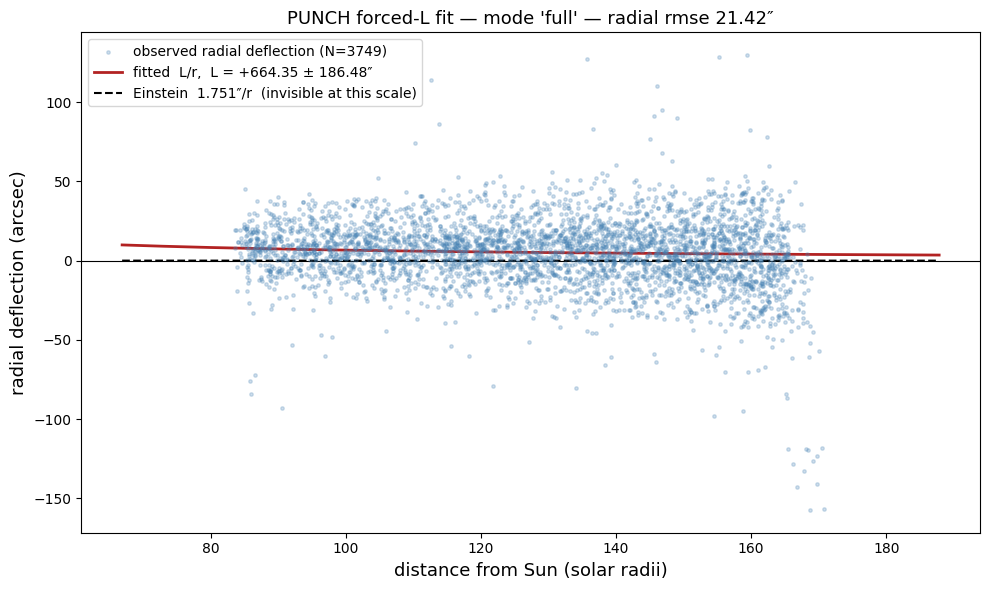

saved plot     : PUNCH_TAB3_DEFLECTIONS_full_20260710160929.png
saved results  : PUNCH_TAB3_L_RESULT_full_20260710160929.txt

PUNCH 'Tab 3' Equivalent — Forced L Measurement
mode                : full
input frame         : PUNCH_L3_CAM_20260219001600_v0j.fits
observation         : 2026-02-19T00:16:00.000
plate scale         : 81.000 arcsec/px
stars used          : 3749
r range (R_sun)     : 83.6 - 170.7

Nelder-Mead (Tab 3 error_function1):
  L = +696.4013 arcsec   rms = 28.171 arcsec

Method 1 (OLS 1/r, plate scale fixed):
  L = +664.3539 +/- 186.4817 arcsec
  radial rmse = 21.417 arcsec
  vs accepted L = 1.751: measured/accepted = +379.4x, |L|/sigma = 3.56

Method 2 (OLS 1/r + r, scale term free):
  L = +1192.9696 +/- 118.7605 arcsec
  fitted plate scale = 80.997087 arcsec/px
  radial rmse = 21.353 arcsec

VERDICT:
  The fit runs end-to-end, but sigma_L = 186.5 arcsec is 107x the accepted L = 1.751 arcsec.
  L is statistically consistent with anything from large-negative to large-pos

In [5]:
# ============================================================================
# PLOTS + RESULTS FILE (Tab 3's ECLIPSE_OUTPUT / deflection-scatter equivalents)
# ============================================================================
import datetime
import matplotlib.pyplot as plt

starttime = datetime.datetime.now().strftime("%Y%m%d%H%M%S")

# ---- deflection vs radius, with fitted and Einstein curves ----
fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color="black", lw=0.8)
ax.scatter(rad_dist, deflection_obs, s=40 if MODE == 'top20' else 6,
           alpha=0.9 if MODE == 'top20' else 0.25, c="steelblue",
           label=f"observed radial deflection (N={len(df)})", zorder=3)
xx = np.linspace(max(rad_dist.min() * 0.8, 1), rad_dist.max() * 1.1, 300)
ax.plot(xx, mu1[0] / xx, color="firebrick", lw=2,
        label=f"fitted  L/r,  L = {mu1[0]:+.2f} ± {cov1[0,0]**0.5:.2f}\u2033")
ax.plot(xx, L_ACCEPTED / xx, color="black", ls="--", lw=1.5,
        label=f"Einstein  1.751\u2033/r  (invisible at this scale)")
if MODE == 'top20':
    for _, row in df.iterrows():
        ax.annotate(f"  G={row['magV']:.1f}", (row["r_solar"],
                    deflection_obs[df.index.get_loc(_)]), fontsize=7, color="gray")
ax.set_xlabel("distance from Sun (solar radii)", fontsize=13)
ax.set_ylabel("radial deflection (arcsec)", fontsize=13)
ax.set_title(f"PUNCH forced-L fit — mode '{MODE}' — radial rmse {resid1:.2f}\u2033", fontsize=13)
ax.legend(fontsize=10)
_plot1 = OUTPUT_DIR / f"PUNCH_TAB3_DEFLECTIONS_{MODE}_{starttime}.png"
plt.tight_layout()
plt.savefig(_plot1, dpi=200)
plt.show()

# ---- results file ----
_out_txt = OUTPUT_DIR / f"PUNCH_TAB3_L_RESULT_{MODE}_{starttime}.txt"
with open(_out_txt, "w") as f:
    f.write("PUNCH 'Tab 3' Equivalent — Forced L Measurement\n")
    f.write("=" * 55 + "\n")
    f.write(f"mode                : {MODE}\n")
    f.write(f"input frame         : {PUNCH_FITS.name}\n")
    f.write(f"observation         : {meta['observation_datetime']}\n")
    f.write(f"plate scale         : {platescale0:.3f} arcsec/px\n")
    f.write(f"stars used          : {len(df)}\n")
    f.write(f"r range (R_sun)     : {rad_dist.min():.1f} - {rad_dist.max():.1f}\n\n")
    f.write(f"Nelder-Mead (Tab 3 error_function1):\n")
    f.write(f"  L = {result1.x[0]:+.4f} arcsec   rms = {result1.fun:.3f} arcsec\n\n")
    f.write(f"Method 1 (OLS 1/r, plate scale fixed):\n")
    f.write(f"  L = {mu1[0]:+.4f} +/- {cov1[0,0]**0.5:.4f} arcsec\n")
    f.write(f"  radial rmse = {resid1:.3f} arcsec\n")
    f.write(f"  vs accepted L = {L_ACCEPTED}: measured/accepted = {mu1[0]/L_ACCEPTED:+.1f}x,"
            f" |L|/sigma = {abs(mu1[0])/cov1[0,0]**0.5:.2f}\n\n")
    if RUN_METHOD_2:
        f.write(f"Method 2 (OLS 1/r + r, scale term free):\n")
        f.write(f"  L = {mu2[0]:+.4f} +/- {cov2[0,0]**0.5:.4f} arcsec\n")
        f.write(f"  fitted plate scale = {mu2[1]:.6f} arcsec/px\n")
        f.write(f"  radial rmse = {resid2:.3f} arcsec\n\n")
    f.write("VERDICT:\n")
    _sigma = cov1[0, 0] ** 0.5
    f.write(f"  The fit runs end-to-end, but sigma_L = {_sigma:.1f} arcsec is "
            f"{_sigma/L_ACCEPTED:.0f}x the accepted L = 1.751 arcsec.\n")
    f.write("  L is statistically consistent with anything from large-negative to "
            "large-positive:\n  this measurement CONSTRAINS NOTHING — as predicted by "
            "the plate-scale/noise-floor analysis.\n")

print(f"saved plot     : {_plot1.name}")
print(f"saved results  : {_out_txt.name}")
print()
print(open(_out_txt).read())